In [17]:
# настройка окружения

# # Python 3.12.6
# !pip install optuna==4.1.0
# !pip install opencv-python==4.10.0.84
# !pip install kagglehub==0.3.4
# !pip install matplotlib==3.9.2
# !pip install numpy==2.1.3

In [18]:
from pathlib import Path
from typing import Iterator
import json

import random
import numpy as np
import kagglehub
import matplotlib.pyplot as plt
import cv2
import optuna

# > Детектирование штрихкодов на продуктах

## Описание задачи
Мы будем изучать возможности OpenCV на примере решения практической задачи. Представьте, что вы разрабатываете приложение для учёта товаров в продуктовом магазине. Продавец фотографирует поступивший товар, приложение распознаёт штрихкод и фиксирует товар в базе данных.

Ключевым этапом в этой задаче является детектирование штрихкода на фотографии. Для решения мы реализуем алгоритм для детекции штрихкодов, научимся оценивать его качество и настроим его на основе наших данных.

# План
Задание будет состоять из 5 этапов:

1. **Подготовка данных**: здесь мы скачаем данные и подготовим их для дальнейшей работы.

2. **Оценка качества**: реализуем метрики `IoU` и `Accuracy` для оценки качества работы алгоритма детекции.

3. **Подготовка пайплайна**: подготовим пайплайн, состоящий из чтения данных, мок-алгоритма детекции и оценки качества.

4. **Алгоритм детекции**: реализуем алгоритм детекции штрихкодов на основе классических методов компьютерного зрения.

5. **Настройка параметров**: научимся автоматически подбирать параметры алгоритма на основе наших данных.


# > Подготовка данных

Задачу детектирования штрихкодов мы будем рассматривать на примере небольшого [датасета](https://www.kaggle.com/datasets/trainingdatapro/ocr-barcodes-detection) с kaggle. Он состоит из фотографий продуктов, на которых виден штрихкод. Данный датасет можно скачать напрямую с kaggle, используя библиотеку `kagglehub`:

In [19]:
dataset_name = "trainingdatapro/ocr-barcodes-detection"
dataset_path = kagglehub.dataset_download(dataset_name)

Вот пример одной из фотографий:

In [20]:
dataset_path

'/kaggle/input/datasets/trainingdatapro/ocr-barcodes-detection'

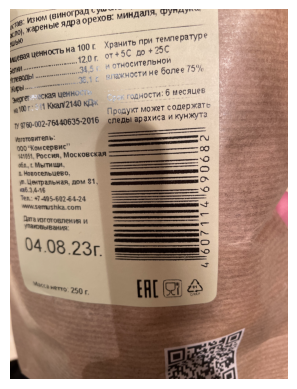

In [21]:
image_path = Path(dataset_path).joinpath('images/3.png')
image = cv2.imread(image_path)

plt.axis('off')
plt.imshow(image[:, :, ::-1])
plt.show()

Исходная разметка датасета содержит координаты номеров штрихкодов, поэтому она нам не подойдёт. Мы адаптировали её, чтобы разметка содержала координаты штрихкодов. Файл с разметкой (annotation.json) можно скачать [тут](https://disk.yandex.ru/d/bBQrGFNmAU0vXA).


## Поиск путей к изображениям в датасете

**Задание 1**. Цель этого задания — научиться работать с файловой системой для извлечения путей к изображениям из датасета. Вам необходимо написать функцию, которая на вход будет принимать корневой путь к датасету, а на выход — возвращать генератор, который будет поочерёдно выдавать пути к изображениям. Для дальнейшей работы нам понадобятся все изображения формата `.png` из датасета.

Нужные нам изображения лежат в папке images. 

> В данном случае использование генератора вместо списка не даст нам значительных преимуществ, так как мы работаем с маленьким датасетом, однако лучше сразу привыкать работать с генераторами и не загружать все данные в память, при работе с большими датасетами это сильно помогает.

In [22]:
def get_image_paths_generator(dataset_path: str) -> Iterator:
    """
    Возвращает итератор, выдающий пути ко всем .png-изображениям в папке dataset_path.
    Изображения могут лежать во вложеных папках.

    :param dataset_path: Корневой путь к датасету.
    :return: Итератор путей к изображениям.
    """
    # Ваш код здесь
    for i in range(11):
        yield Path(dataset_path).joinpath(f'mock_dataset/image_{i}.png')

In [23]:
files = get_image_paths_generator(dataset_path)
print(next(files))


/kaggle/input/datasets/trainingdatapro/ocr-barcodes-detection/mock_dataset/image_0.png


In [24]:
# Решение автора
def get_image_paths_generator(dataset_path: str) -> Iterator:
    """
    Возвращает итератор, выдающий пути ко всем .png-изображениям в папке dataset_path.

    :param dataset_path: Корневой путь к датасету.
    :return: Итератор путей к изображениям.
    """
    image_paths = Path(dataset_path).rglob('*.png')
    return image_paths

In [25]:
files = get_image_paths_generator(dataset_path)
print(next(files))

/kaggle/input/datasets/trainingdatapro/ocr-barcodes-detection/boxes/4.png


## Чтение разметки в формате JSON

**Задание 2**. В этом задании вы напишете код для чтения разметки из файла в формате JSON. Для этого нам понадобится файл `annotation.json`, который вы скачали перед предыдущим заданием. Если вы работаете в google collab, вам понадобится загрузить файл в «сессионное хранилище».

Формат разметки представлен в виде JSON-файла, содержащего словарь с ключами в виде названия изображения и значениями в виде координат четырёхугольника:

``` python
{'image_name': [[x1, y1], [x2, y2], [x3, y3], [x4, y4]]}
```
Вам необходимо написать функцию, которая на вход принимает путь к JSON-файлу, а на выход возвращает словарь с разметкой.

In [26]:
json_file_path = "/kaggle/input/datasets/andreykurdyubov/annotation-cv-hw1/annotation.json"
with open(json_file_path, 'r') as f:
    d = json.load(f)
print(d)

{'0.png': [[1096, 2277], [1096, 1786], [1834, 1790], [1834, 2281]], '1.png': [[1270, 2534], [1271, 2201], [2185, 2213], [2183, 2546]], '2.png': [[954, 1579], [2057, 1485], [2065, 2376], [962, 2470]], '3.png': [[1063, 1275], [2169, 1274], [2179, 2718], [1072, 2718]], '4.png': [[1058, 2186], [2518, 2161], [2520, 2688], [1060, 2714]], '5.png': [[1484, 2542], [1485, 2063], [2299, 2079], [2298, 2558]], '6.png': [[703, 1851], [1944, 1707], [1957, 2312], [715, 2456]], '7.png': [[1362, 2538], [2322, 2493], [2325, 2872], [1366, 2917]], '8.png': [[1294, 2748], [1295, 2267], [2293, 2283], [2291, 2764]], '9.png': [[1114, 3016], [1122, 1599], [1881, 1600], [1872, 3017]], '10.png': [[1370, 3364], [1408, 1889], [1995, 1892], [1957, 3368]]}


In [27]:
def read_json_annotation(json_file_path: str) -> dict:
    """
    Читает файл разметки JSON и возвращает его в виде словаря.

    :param json_file_path: Путь к JSON-файлу с разметкой.
    :return: Словарь, где ключ — это название изображения, а значение — координаты четырёхугольника.
    """
    # Ваш код здесь
    anno = None
    with open(json_file_path, 'r') as f:
        anno = json.load(f)
    return anno

annotation = read_json_annotation(json_file_path)
annotation

{'0.png': [[1096, 2277], [1096, 1786], [1834, 1790], [1834, 2281]],
 '1.png': [[1270, 2534], [1271, 2201], [2185, 2213], [2183, 2546]],
 '2.png': [[954, 1579], [2057, 1485], [2065, 2376], [962, 2470]],
 '3.png': [[1063, 1275], [2169, 1274], [2179, 2718], [1072, 2718]],
 '4.png': [[1058, 2186], [2518, 2161], [2520, 2688], [1060, 2714]],
 '5.png': [[1484, 2542], [1485, 2063], [2299, 2079], [2298, 2558]],
 '6.png': [[703, 1851], [1944, 1707], [1957, 2312], [715, 2456]],
 '7.png': [[1362, 2538], [2322, 2493], [2325, 2872], [1366, 2917]],
 '8.png': [[1294, 2748], [1295, 2267], [2293, 2283], [2291, 2764]],
 '9.png': [[1114, 3016], [1122, 1599], [1881, 1600], [1872, 3017]],
 '10.png': [[1370, 3364], [1408, 1889], [1995, 1892], [1957, 3368]]}

# > Оценка качества
Прежде чем приступить к построению пайплайна для детекции, необходимо определить способы оценки качества нашего алгоритма.

## Intersection over Union

Для задач детекции объектов часто используется метрика `Intersection over Union (IoU)`. `IoU` измеряет, насколько точно обнаружен объект на изображении, путём сравнения площади пересечения предсказанной и истинной границ с площадью их объединения.

Для реализации `IoU` вам потребуется несколько вспомогательных функций:

- `convert_to_rectangle_coords()`
- `area()`

**Задание 3**. Реализуйте функцию `convert_to_rectangle_coords()` для поиска координат прямоугольника, который будет описывать многоугольник, который мы получаем на вход функции. Это позволит нам упростить расчёт метрики, так как не обязательно, что данные, которые будут поступать к нам на вход, являются прямоугольниками.

In [28]:
def convert_to_rectangle_coords(bbox: list) -> list:
    """
    Выдаёт координаты прямоугольника, описывающего входной bbox.

    :param bbox: Список вершин четырёхугольника в формате [[x1, y1], [x2, y2], [x3, y3], [x4, y4]]
    :return coords: Координаты вершин прямоугольника в формате [[x_min, y_min], [x_max, y_max]]
    """
    coords = np.array(bbox)
    x_min, y_min = np.min(coords, axis=0).tolist()
    x_max, y_max = np.max(coords, axis=0).tolist()
    return [[x_min, y_min], [x_max, y_max]]

bbox = [[0, 1], [2, -1], [-2, 3], [4, 5]]
convert_to_rectangle_coords(bbox)

[[-2, -1], [4, 5]]

In [29]:
# решение автора

def convert_to_rectangle_coords(bbox: list) -> list:
    """
    Выдаёт координаты прямоугольника, описывающего входной bbox.

    :param bbox: Список вершин четырёхугольника в формате [[x1, y1], [x2, y2], ..., [xn, yn]]
    :return coords: Координаты вершин прямоугольника в формате [[x_min, y_min], [x_max, y_max]]
    """
    x_coords = [x for x, y in bbox]
    y_coords = [y for x, y in bbox]
    x_min, x_max = min(x_coords), max(x_coords)
    y_min, y_max = min(y_coords), max(y_coords)
    coords = [[x_min, y_min], [x_max, y_max]]
    return coords

**Задание 4**. Реализуйте функцию `area()` для подсчёта площади прямоугольника. Если на вход переданы невалидные координаты, то площадь должна равняться 0.

In [30]:
def area(coords: list) -> int:
  """
  Вычисляет площадь прямоугольника.

  :param bbox: Координаты вершин прямоугольника в формате [[x_min, y_min], [x_max, y_max]]
  :return area: Площадь прямоугольника,  0 если входные координаты не валидные.
  """
  # Ваш код здесь  
  try:      
      [[x_min, y_min], [x_max, y_max]] = coords
      x_length = x_max - x_min
      y_length = y_max - y_min
  except (ValueError, TypeError):
      return 0
  
  if x_length < 0 or y_length < 0:
      return 0

  return x_length * y_length

area([[2, 1], [1, -5]])

0

In [31]:
# решение автора
def area(coords: list) -> int:
  """
  Вычисляет площадь прямоугольника.

  :param bbox: Координаты вершин прямоугольника в формате [[x_min, y_min], [x_max, y_max]]
  :return area: Площадь прямоугольника, 0 если входные координаты не валидные.
  """
  x_min, y_min = coords[0]
  x_max, y_max = coords[1]
  area = max(0, x_max - x_min) * max(0, y_max - y_min)
  return area

**Задание 5**. Теперь можно приступить к реализации самой метрики `IoU`. Она рассчитывается достаточно просто. У нас есть 2 прямоугольника, один является верной разметкой, второй — предсказанием алгоритма. Как можно догадаться из названия метрики, нам необходимо найти их площадь, их пересечения, найти площадь их объединения и поделить одно на другое.

In [32]:
def dot_inside(bbox: list, dot: list) -> bool:
    """
    bbox = [[x_min, y_min], [x_max, y_max]]
    dot = [x, y]
    check dot inside bbox
    """
    [[x_min, y_min], [x_max, y_max]] = bbox
    x, y = dot
    return x_min <= x <= x_max and y_min <= y <= y_max

def line_intersect(line1: list, line2: list) -> list:
    """
    line1 = [[x1, y1], [x1, y2]] # vertical line   x1: y1 - y2
    line2 = [[x3, y3], [x4, y3]] # horizontal line y3: x3 - x4
    return intersection dot
    """
    x1, y1 = line1[0]
    y2 = line1[1][1]
    x3, y3 = line2[0]
    x4 = line1[1][0]
    if x3 <= x1 <= x4 and y1 <= y3 <= y2:
        return (x1, y3)
    return None
    

bbox = [[0, -1], [1, 5]]
print(dot_inside(bbox, [0, 0]))
line1 = [[0, 0], [0, 4]]
line2 = [[-4, 4], [5, 4]]
print(line_intersect(line1, line2))

def inter_box(box1: list, box2: list) -> list:
    """
    find intersection of two boxes
    box1 = [[x1, y1], [x2, y2]]  # left bottom - right top
    box2 = [[x3, y3], [x4, y4]]  # left bottom - right top
    """
    [[x1, y1], [x2, y2]] = box1
    [[x3, y3], [x4, y4]] = box2
    
    coords1 = [[x1, y1], [x1, y2], [x2, y2], [x2, y1]]  # coordinates box1
    coords2 = [[x3, y3], [x3, y4], [x4, y4], [x4, y3]]  # coordinates box2
    
    v1 = [coords1[0], coords1[1]]  # left vertical
    v2 = [coords1[3], coords1[2]]  # right vertical
    v3 = [coords2[0], coords2[1]]  # left vertical
    v4 = [coords2[3], coords2[2]]  # right vertical
    
    h1 = [coords1[0], coords1[3]]  # bottom horizontal
    h2 = [coords1[1], coords1[2]]  # top horizontal
    h3 = [coords2[0], coords2[3]]  # bottom horizontal
    h4 = [coords2[1], coords2[2]]  # top horizontal
    
    corners = []
    
    for dot in coords1:
        if dot_inside(box2, dot):
            corners.append(tuple(dot))
    
    for dot in coords2:
        if dot_inside(box1, dot):
            corners.append(tuple(dot))
    
    li = line_intersect
    corners.extend([li(v1, h3), li(v1, h4), 
                    li(v2, h3), li(v2, h4),
                    li(v3, h1), li(v3, h2), 
                    li(v4, h1), li(v4, h1)]
                  )
    corners = list(set(corners) - set([None]))
    if len(corners) < 4:
        return None
        
    return convert_to_rectangle_coords(corners)

x1, y1, x2, y2 = 0, 0, 5, 5
x3, y3, x4, y4 = -1, -1, 0, 0
box1 = [[x1, y1], [x2, y2]]
box2 = [[x3, y3], [x4, y4]]
inter_box(box1, box2)

True
(0, 4)


In [33]:
def dot_inside(bbox: list, dot: list) -> bool:
    """
    bbox = [[x_min, y_min], [x_max, y_max]]
    dot = [x, y]
    check dot inside bbox
    """
    [[x_min, y_min], [x_max, y_max]] = bbox
    x, y = dot
    return x_min <= x <= x_max and y_min <= y <= y_max

def line_intersect(line1: list, line2: list) -> list:
    """
    line1 = [[x1, y1], [x1, y2]] # vertical line   x1: y1 - y2
    line2 = [[x3, y3], [x4, y3]] # horizontal line y3: x3 - x4
    return intersection dot
    """
    x1, y1 = line1[0]
    y2 = line1[1][1]
    x3, y3 = line2[0]
    x4 = line2[1][0]
    if x3 <= x1 <= x4 and y1 <= y3 <= y2:
        return (x1, y3)
    return None

def inter_box(box1: list, box2: list) -> list:
    """
    find intersection of two boxes
    box1 = [[x1, y1], [x2, y2]]  # left bottom - right top
    box2 = [[x3, y3], [x4, y4]]  # left bottom - right top
    """
    [[x1, y1], [x2, y2]] = box1
    [[x3, y3], [x4, y4]] = box2
    
    coords1 = [[x1, y1], [x1, y2], [x2, y2], [x2, y1]]  # coordinates box1
    coords2 = [[x3, y3], [x3, y4], [x4, y4], [x4, y3]]  # coordinates box2
    
    v1 = [coords1[0], coords1[1]]  # left vertical
    v2 = [coords1[3], coords1[2]]  # right vertical
    v3 = [coords2[0], coords2[1]]  # left vertical
    v4 = [coords2[3], coords2[2]]  # right vertical
    
    h1 = [coords1[0], coords1[3]]  # bottom horizontal
    h2 = [coords1[1], coords1[2]]  # top horizontal
    h3 = [coords2[0], coords2[3]]  # bottom horizontal
    h4 = [coords2[1], coords2[2]]  # top horizontal
    
    corners = []
    # add all corners inside other box
    for dot in coords1:
        if dot_inside(box2, dot):
            corners.append(tuple(dot))
    
    for dot in coords2:
        if dot_inside(box1, dot):
            corners.append(tuple(dot))

    # add all line intersections
    li = line_intersect
    corners.extend([li(v1, h3), li(v1, h4), 
                    li(v2, h3), li(v2, h4),
                    li(v3, h1), li(v3, h2), 
                    li(v4, h1), li(v4, h2)]
                  )
    
    corners = list(set(corners) - set([None]))
    if len(corners) < 4:
        return None
    print(corners)
    inter_box = convert_to_rectangle_coords(corners)    
    print(inter_box)
    return inter_box

def calculate_iou(box_pred, box_true):
    """
    Вычисляет Intersection over Union для двух четырёхугольников.
    
    :param box_pred: Список вершин четырёхугольника в формате [[x1, y1], [x2, y2], [x3, y3], [x4, y4]] для предсказанного bbox.
    :param box_true: Список вершин четырёхугольника в формате [[x1, y1], [x2, y2], [x3, y3], [x4, y4]] для истинного bbox.
    :return: Значение IoU от 0 до 1.
    """
    
    # Получите координаты прямоугольников, описывающих предсказанный bbox и разметку
    pred_bbox = convert_to_rectangle_coords(box_pred)
    true_bbox = convert_to_rectangle_coords(box_true)
    
    # Вычислите координаты прямоугольника пересечения pred_bbox и true_bbox
    inter_bbox = inter_box(pred_bbox, true_bbox)
    
    # Вычислите площадь прямоугольника пересечения
    if inter_bbox:
      inter_area = area(inter_bbox)
    else:
      return 0
    
    # Вычисляем площадь прямоугольников pred_bbox и true_bbox
    area_pred = area(pred_bbox)
    area_true = area(true_bbox)
    
    # Вычислите IoU
    iou = inter_area/(area_pred + area_true - inter_area)
    return iou

In [34]:
x1, y1, x2, y2 = 0, 0, 5, 5
x3, y3, x4, y4 = -1, -1, 0, 1
box1 = [[x1, y1], [x2, y2]]
box2 = [[x3, y3], [x4, y4]]
calculate_iou(box1, box2)

0

In [35]:
# решение автора

def calculate_iou(box_pred, box_true):
  """
  Вычисляет Intersection over Union для двух четырёхугольников.

  :param box_pred: Список вершин четырёхугольника в формате [[x1, y1], [x2, y2], [x3, y3], [x4, y4]] для предсказанного bbox.
  :param box_true: Список вершин четырёхугольника в формате [[x1, y1], [x2, y2], [x3, y3], [x4, y4]] для истинного bbox.
  :return: Значение IoU от 0 до 1.
  """

  # Получаем координаты прямоугольников, описывающих каждый четырёхугольник
  pred_bbox = convert_to_rectangle_coords(box_pred)
  pred_x_min, pred_y_min = pred_bbox[0]
  pred_x_max, pred_y_max = pred_bbox[1]

  true_bbox = convert_to_rectangle_coords(box_true)
  true_x_min, true_y_min = true_bbox[0]
  true_x_max, true_y_max = true_bbox[1]

  # Вычисляем (x, y) — координаты прямоугольника пересечения
  x_min_inter = max(pred_x_min, true_x_min)
  y_min_inter = max(pred_y_min, true_y_min)
  x_max_inter = min(pred_x_max, true_x_max)
  y_max_inter = min(pred_y_max, true_y_max)

  # Вычисляем площадь прямоугольника пересечения
  inter_area = area([[x_min_inter, y_min_inter], [x_max_inter, y_max_inter]])

  # Вычисляем площадь прямоугольников
  pred_area = area([[pred_x_min, pred_y_min],[pred_x_max, pred_y_max]])
  true_area = area([[true_x_min, true_y_min],[true_x_max, true_y_max]])


  # Вычисляем IoU
  iou = inter_area / (pred_area + true_area - inter_area)
  return iou

**Задание 6**. Алгоритм детекции может выдавать несколько потенциальных областей (предиктов) для каждого изображения. Поскольку важно удостовериться, что хотя бы один из предиктов соответствует истинному положению штрихкода, мы будем использовать следующий подход: для каждого изображения выберем максимальное значение `IoU`, достигнутое при сравнении всех предсказанных областей с истинной разметкой.

In [36]:
def max_iou(predicts: list, gt: list) -> float:
    """
    Вычисляет максимальный показатель IoU для заданного списка предиктов по отношению к разметке для этого файла.
    
    :param predicts: Список предиктов, каждый из которых в формате [[x1, y1], [x2, y2], [x3, y3], [x4, y4]]
    :param gt: Разметка в формате [[x1, y1], [x2, y2], [x3, y3], [x4, y4]]
    
    :return: Максимальное значение IoU среди всех предсказанных областей. Если предсказанных областей нет, возвращается 0.0.
    """
    if not predicts: 
      return 0
    
    max_iou = 0
    for predict in predicts:
        if calculate_iou(predict, gt) > max_iou:
            max_iou = calculate_iou(predict, gt)
    return max_iou

## Accuracy
После реализации метрики для оценки качества модели на одном изображении мы переходим к оценке работы модели на всём наборе данных через метрику точности (accuracy). Эта метрика определяет, какой процент изображений был предсказан правильно — то есть для каких изображений значение IoU превышает заданный порог.

**Задание 7**. Напишите функцию `calculate_accuracy()`, которая принимает на вход список значений IoU для каждого изображения и возвращает значение точности (accuracy) на основе заданного порогового значения IoU.

In [37]:
def calculate_accuracy(iou_scores: list, iou_th: float) -> float:
    """
    Вычисляет точность (accuracy) для заданного списка IoU с учётом порогового значения.

    :param iou_scores: Список значений IoU для каждого изображения.
    :param iou_th: Пороговое значение IoU, выше которого предсказание считается успешным.

    :return: Значение точности, представляющее собой долю изображений с IoU выше порога.
    """
    # Ваш код здесь
    if len(iou_scores) == 0:
        return 0
        
    count = 0
    for iou in iou_scores:
        if iou > iou_th:
             count += 1
    return count / len(iou_scores)

calculate_accuracy([.1, .2, .3, .4, .5, .6], .24)
calculate_accuracy([], .24)

0

In [38]:
# решение автора

def calculate_accuracy(iou_scores: list, iou_th: float) -> float:
    """
    Вычисляет точность (accuracy) для заданного списка IoU с учётом порогового значения.

    :param iou_scores: Список значений IoU для каждого изображения.
    :param iou_th: Пороговое значение IoU, выше которого предсказание считается успешным.

    :return: Значение точности, представляющее собой долю изображений с IoU выше порога.
    """
    predicts = np.array(iou_scores) > iou_th
    if len(predicts) == 0:
        return 0.0
    else:
        accuracy = sum(predicts) / len(predicts)
    return accuracy

# > Подготовка пайплайна

Половина задачи уже решена. Теперь мы имеем метрику качества, на которую можем ориентироваться при решении задачи. Наличие метрики качества перед началом работы над алгоритмом крайне важно, так как она предоставляет ясные критерии, позволяющие объективно оценивать и улучшать работу алгоритма по мере его разработки.

Теперь, когда у нас есть метрики, мы можем приступить к реализации основного пайплайна для решения задачи. Пайплайн будет состоять из следующих шагов: чтение исходных данных, предсказание координат штрихкодов нашим алгоритмом и оценка качества предсказаний.

Так как конкретный алгоритм детекции мы пока не реализовали, мы начнём с создания заглушки — так называемого «mock»-алгоритма — чтобы иметь возможность отладить наш пайплайн. Это позволит убедиться, что все части процесса правильно взаимодействуют между собой.

## Mock-алгоритм

**Задание 8**. Mock-алгоритм может иметь любую простую реализацию, но важно, чтобы он имел тот же интерфейс, что и предполагаемый реальный алгоритм. В качестве примера мы реализуем простой алгоритм, который принимает на вход изображение и возвращает координаты случайного прямоугольника.

Реализуйте класс `MockBarcodeDetector`, для которого при инициализации указывается, какое количество случайных координат прямоугольников он должен выдавать, и реализуйте метод `detect_barcode`, на вход которому будет поступать изображение, а на выход — `n` случайных координат прямоугольников.

In [39]:
class MockBarcodeDetector:
    def __init__(self, n:int):
        """
        Инициализирует mock-детектор с заданным числом предсказаний.
        
        :param n: Количество случайных предсказаний, которые будут сгенерированы для каждого изображения.
        """
        self.n = n
    
    def detect_barcode(self, image: np.ndarray) -> list:
        """
        Генерирует список случайных предсказаний штрихкодов на изображении.
        
        :param image: Входное изображение в формате numpy-массива.
        :return: Список с координатами предсказанных штрихкодов, где каждый элемент списка представлен
                  четырьмя угловыми точками прямоугольника в формате [[x1, y1], [x1, y2], [x2, y2], [x2, y1]].
        """
        # Ваш код здесь
        out = []
        shape_x, shape_y = image.shape[:2]
        for _ in range(self.n):
            x1_x2 = np.random.randint(shape_x, size=2); x1_x2.sort()
            x1, x2 = x1_x2.tolist()
            y1_y2 = np.random.randint(shape_y, size=2); y1_y2.sort()
            y1, y2 = y1_y2.tolist()
            out.append([[x1, y1], [x1, y2], [x2, y2], [x2, y1]])
        return out


In [40]:
image_paths = get_image_paths_generator(dataset_path)
image = cv2.imread(next(image_paths))
print(image.shape)
Mock = MockBarcodeDetector(5)
out = Mock.detect_barcode(image)
print(out)


(4032, 3024, 3)
[[[10, 1422], [10, 2399], [2341, 2399], [2341, 1422]], [[584, 905], [584, 938], [2679, 938], [2679, 905]], [[1307, 739], [1307, 2412], [3597, 2412], [3597, 739]], [[1604, 1840], [1604, 2141], [3198, 2141], [3198, 1840]], [[168, 443], [168, 948], [1802, 948], [1802, 443]]]


In [41]:
# решение автора
class MockBarcodeDetector:
    def __init__(self, n:int):
        """
        Инициализирует mock-детектор с заданным числом предсказаний.
        
        :param n: Количество случайных предсказаний, которые будут сгенерированы для каждого изображения.
        """
        self.n = n
    
    def detect_barcode(self, image: np.ndarray) -> list:
        """
        Генерирует список случайных предсказаний штрихкодов на изображении.
        
        :param image: Входное изображение в формате numpy-массива.
        :return: Список с координатами предсказанных штрихкодов, где каждый элемент списка представлен
                  четырьмя угловыми точками прямоугольника в формате [[x1, y1], [x1, y2], [x2, y2], [x2, y1]].
        """
        coords = []
        for i in range(self.n):
            height, width, _ = image.shape
            
            x1 = random.randint(0, width - 1)
            y1 = random.randint(0, height - 1)
            
            x2 = random.randint(x1, width - 1)
            y2 = random.randint(y1, height - 1)
            
            coords.append([[x1, y1], [x1, y2], [x2, y2], [x2, y1]])
        return  coords

## Построение и запуск пайплайна детекции

**Задание 9**. Теперь мы готовы реализовать полный пайплайн для детекции штрихкодов и оценки качества алгоритма. Этот пайплайн включает в себя все компоненты, которые мы обсуждали на предыдущих этапах: загрузку данных, предсказание координат штрихкодов и оценку качества работы алгоритма.

Функция `pipeline` выполняет следующие задачи:

1. **Загрузка набора данных**: используем функцию `kagglehub.dataset_download` для загрузки изображений.

2. **Получение путей к изображениям**: работает с генератором `get_image_paths_generator`.

3. **Чтение разметки**: использует функцию `read_json` для извлечения истинных координат штрихкодов.

4. **Предсказание и оценка**: применяет mock-алгоритм для предсказания и рассчитывает IoU для каждого предсказания. Сохраняет максимальные IoU в список.

5. **Вычисление точности (accuracy)**: использует созданную функцию  `calculate_accuracy` для расчёта доли правильно предсказанных изображений на всём датасете.

**Реализуйте пайплайн**:

In [58]:
import re

def pipeline(barcode_detector, image_paths, annotation, iou_th):
    """
    Реализация пайплайна для детекции штрих-кодов и оценки качества модели.

    :param barcode_detector: реализация класса для детекции штрих-кодов.
    :param image_paths: Генератор путей к изображениям.
    :param annotation: Словарь с истинной разметкой изображений.
    :param iou_th: Пороговое значение IoU для успешного детектирования.

    :return: Точность (accuracy) модели.
    """
    # ваш код здесь
    iou_scores = []

    for image_path in image_paths:
        path_str = str(image_path)
        match = re.search(r'/(\d+\.png)$', path_str)
        if match:
            filename = match.group(1)
        else: 
            return
        true_coords = annotation[filename]
        
        image = cv2.imread(image_path)
        coords = barcode_detector.detect_barcode(image)
        iou_scores.append(max_iou(coords, true_coords))
        
    return calculate_accuracy(iou_scores, iou_th)

Теперь мы можем запустить наш пайплайн и оценить точность алгоритма, который выдаёт случайные координаты:

In [62]:
PATH_TO_DATASET = 'trainingdatapro/ocr-barcodes-detection'
PATH_TO_ANNOTAION = '/kaggle/input/datasets/andreykurdyubov/annotation-cv-hw1/annotation.json'
IOU_TH = 0.5

dataset_path = kagglehub.dataset_download(PATH_TO_DATASET)
image_paths = get_image_paths_generator(dataset_path)
annotation = read_json_annotation(PATH_TO_ANNOTAION)
barcode_detector = MockBarcodeDetector(n=2)

# accuracy = pipeline(barcode_detector, image_paths, annotation, IOU_TH)
# accuracy

In [68]:
im = next(image_paths)
print(dir(im))
print(im.stem, im.name, im.suffix, im.parent)

['__bytes__', '__class__', '__delattr__', '__dir__', '__doc__', '__enter__', '__eq__', '__exit__', '__format__', '__fspath__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__rtruediv__', '__setattr__', '__sizeof__', '__slots__', '__str__', '__subclasshook__', '__truediv__', '_drv', '_flavour', '_format_parsed_parts', '_from_parsed_parts', '_hash', '_lines', '_lines_cached', '_load_parts', '_make_child_relpath', '_parse_path', '_parts_normcase', '_parts_normcase_cached', '_raw_paths', '_root', '_scandir', '_str', '_str_normcase', '_str_normcase_cached', '_tail', '_tail_cached', 'absolute', 'anchor', 'as_posix', 'as_uri', 'chmod', 'cwd', 'drive', 'exists', 'expanduser', 'glob', 'group', 'hardlink_to', 'home', 'is_absolute', 'is_block_device', 'is_char_device', 'is_dir', 'is_fifo', 'is_file', 'is_junction', 'is_mount', 'is_relative_to',

In [51]:

path_str = str(next(image_paths))
match = re.search(r'/(\d+\.png)$', path_str)
if match:
    filename = match.group(1)
    print(filename)  # Выведет: 4.png

2.png


In [47]:
annotation

{'0.png': [[1096, 2277], [1096, 1786], [1834, 1790], [1834, 2281]],
 '1.png': [[1270, 2534], [1271, 2201], [2185, 2213], [2183, 2546]],
 '2.png': [[954, 1579], [2057, 1485], [2065, 2376], [962, 2470]],
 '3.png': [[1063, 1275], [2169, 1274], [2179, 2718], [1072, 2718]],
 '4.png': [[1058, 2186], [2518, 2161], [2520, 2688], [1060, 2714]],
 '5.png': [[1484, 2542], [1485, 2063], [2299, 2079], [2298, 2558]],
 '6.png': [[703, 1851], [1944, 1707], [1957, 2312], [715, 2456]],
 '7.png': [[1362, 2538], [2322, 2493], [2325, 2872], [1366, 2917]],
 '8.png': [[1294, 2748], [1295, 2267], [2293, 2283], [2291, 2764]],
 '9.png': [[1114, 3016], [1122, 1599], [1881, 1600], [1872, 3017]],
 '10.png': [[1370, 3364], [1408, 1889], [1995, 1892], [1957, 3368]]}

In [60]:
# решение автора
def pipeline(barcode_detector, image_paths, annotation, iou_th):
    """
    Реализация пайплайна для детекции штрихкодов и оценки качества модели.

    :param barcode_detector: Реализация класса для детекции штрихкодов.
    :param image_paths: Генератор путей к изображениям.
    :param annotation: Словарь с истинной разметкой изображений.
    :param iou_th: Пороговое значение IoU для успешного детектирования.

    :return: Точность (accuracy) модели.
    """
    iou_scores = []

    for image_path in image_paths:
        image = cv2.imread(str(image_path))
        image_name = image_path.name
        gt = annotation[image_name]
        predictions = barcode_detector.detect_barcode(image)
        iou = max_iou(predictions, gt)
        iou_scores.append(iou)
    print(f"IoU scores: {iou_scores}")
    accuracy = calculate_accuracy(iou_scores, iou_th)
    print(f"Accuracy: {accuracy:.2f}")
    return accuracy

Запустив пайплайн с mock-алгоритмом, вы, скорее всего, получите нулевую точность, что неудивительно, так как предсказания случайны. Но это не главное.

Теперь у вас есть мощный инструмент для экспериментов и проверки гипотез. Готовый пайплайн позволяет сосредоточиться на решении задачи детекции штрихкодов. Вы можете быстро тестировать и улучшать свои алгоритмы, заменяя mock-алгоритм на более сложные подходы.

# > Алгоритм детекции

**Задание 10**. Теперь нам необходимо реализовать наш алгоритм для детекции штрихкодов.

1. **Размытие изображения**: на первом этапе мы применяем размытие к входному изображению, чтобы уменьшить шум и мелкие детали, которые могут помешать дальнейшим операциям обнаружения контуров. Это достигается с помощью усредняющего фильтра.

2. **Выявление тёмных областей**: на втором этапе мы преобразуем изображение в цветовое пространство HSV и определяем маску тёмных областей на основе значений яркости. Это помогает выделить потенциальные области, содержащие штрихкоды.

3. **Морфологическая обработка (замыкание)**: на третьем этапе мы применяем морфологическое замыкание, состоящее из дилатации и эрозии. Это помогает заполнить пробелы и соединить разорванные части в областях, выделенных на предыдущем этапе.

4. **Обнаружение контуров**: на четвёртом этапе мы будем искать контуры, которые потенциально содержат штрихкоды.

In [44]:
class BarcodeDetector:
  def __init__(self,
               blur_kernel,
               min_value, max_value,
               closing_kernel,
               ):
    self.blur_kernel = blur_kernel
    self.min_value = min_value
    self.max_value = max_value
    self.closing_kernel = closing_kernel

  def detect_barcode(self, image: np.ndarray) -> list:
    """
    Пайплайн для детекции штрихкодов на изображении.

    :param image: Входное изображение, на котором необходимо обнаружить штрихкоды.
    :return: Список контуров штрихкодов.
    """
    blured_image = self.apply_blur(image)
    dark_areas = self.find_dark_areas(blured_image)
    closed_image = self.closing(dark_areas)
    barcodes_contours = self.detect_contours(closed_image)
    return barcodes_contours

  def apply_blur(self, image):
    """
    Применяет размытие к изображению.

    :param image: Входное изображение.
    :return: Размазанное изображение.
    """
    # Ваш код здесь
    pass

  def find_dark_areas(self, image):
    """
    Находит тёмные области на изображении, основываясь на значении яркости в цветовом пространстве HSV.

    :param image: Входное изображение в формате BGR, на котором нужно обнаружить тёмные области.
                  Должно быть представлено как numpy.ndarray.
    :return: Маска, где пиксели, соответствующие тёмным областям, имеют значение 1, а все остальные — 0.
            Представлено в виде numpy.ndarray с теми же высотой и шириной, что и входное изображение.
    """
    # Нужно перевести изображение в HSV-формат
    # В канале яркости определить маску, ограничивающую яркость от self.min_value до self.max_value
    # Привести полученную маску к размерности (h,w,1)
    pass

  def closing(self, image: np.ndarray) ->  np.ndarray:
    """
    Выполняет морфологическое замыкание на изображении.

    Морфологическое замыкание включает последовательное выполнение
    операций дилатации и эрозии.

    :param image: Входное изображение, над которым выполняется
    морфологическое замыкание.
    :return:  Изображение после выполнения морфологического замыкания.
    """
    # Ваш код здесь
    pass

  def detect_contours(self, image: np.ndarray) -> np.ndarray:
    """
    Находит контуры и минимальные ограничивающие прямоугольники штрихкодов на изображении.

    :param image: Исходное изображение.
    :param closed_image: Изображение после морфологической обработки.
    :return: Список координат контуров/штрихкодов.
    """
    contours, _ = cv2.findContours(image.copy(), cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
    barcodes_contours = []
    for c in contours:
      rect = cv2.minAreaRect(c)
      box = cv2.boxPoints(rect)
      box = np.intp(box)
      barcodes_contours.append(box.tolist())
    return barcodes_contours

# > Настройка параметров

**Задание 11**. Как правило, алгоритмы, построенные на классических методах компьютерного зрения, требуют тщательной настройки. Алгоритм, настроенный на одном изображении, может плохо работать на другом.

В качестве первого шага можно перебрать настройки алгоритма в некоторых разумных пределах и оценить качество алгоритма на разных данных и при разных параметрах.

Для таких целей одним из инструментов является библиотека `Optuna`, которая позволяет достаточно просто реализовать подбор параметров алгоритма.

Вам нужно будет задать диапазоны, в пределах которых будет происходить подбор параметров. В результате необходимо подобрать такие параметры, при которых точность (accuracy) работы алгоритма на наших данных будет больше 0.5.

В качестве ответа вам нужно будет предоставить параметры алгоритма в виде словаря, возвращаемого `study.best_params`.


In [45]:
class Objective:
    def __init__(self, path_to_dataset, path_to_annotation, iou_threshold):
        self.dataset_path = kagglehub.dataset_download(PATH_TO_DATASET)
        self.annotation = read_json_annotation(PATH_TO_ANNOTAION)
        self.iou_threshold = iou_threshold

    def __call__(self, trial):
        blur_kernel = trial.suggest_int('blur_kernel', ..., ..., step=...)
        min_value = trial.suggest_int('min_value', ..., ..., step=...)
        max_value = trial.suggest_int('max_value', ..., ..., step=...)
        closing_kernel = trial.suggest_int('closing_kernel', ..., ..., step=...)


        barcode_detector = BarcodeDetector(
            blur_kernel,
            min_value, max_value,
            closing_kernel
        )

        image_paths = get_image_paths_generator(self.dataset_path)
        accuracy = pipeline(barcode_detector, image_paths, self.annotation, self.iou_threshold)
        return accuracy


PATH_TO_DATASET = 'trainingdatapro/ocr-barcodes-detection'
PATH_TO_ANNOTAION = 'annotation.json'
IOU_TH = 0.5

objective_instance = Objective(PATH_TO_DATASET, PATH_TO_ANNOTAION, IOU_TH)

study = optuna.create_study(direction='maximize')
study.optimize(objective_instance, n_trials=20)

print(f"Максимальная точность: {study.best_value}")
print(f"Оптимальное значение noise_range: {study.best_params}")

FileNotFoundError: [Errno 2] No such file or directory: 'annotation.json'